In [1]:
from pathlib import Path
from torch import multiprocessing
from tqdm import tqdm
import soundfile as sf

In [2]:
import numpy as np
import pandas as pd
import time

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

In [4]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from utils.utils import gen_empty_df
from cfg import get_config

In [5]:
def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_annotations_df,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])
        
    return bd_dets

def apply_models(file_path_mappings, cfg):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a dataframe

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()
    cfg : `dict`
        - A dictionary of pipeline parameters:
        - models is the models in the pipeline that are being used.

    Returns
    ------------
    bd_preds : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    process_pool = multiprocessing.Pool(cfg['num_processes'])

    bd_dets = tqdm(
            process_pool.imap(apply_model, file_path_mappings, chunksize=1), 
            desc=f"Applying BatDetect2",
            total=len(file_path_mappings),
        )
    
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(bd_dets, ignore_index=True)
    
    return bd_preds

def apply_model(file_mapping):
    """
    Runs the batdetect2 model on a single provided audio segmens and corrects the offsets according the segment.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    corrected_bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    print(f"Processing {file_mapping['audio_seg']['audio_file']}")
    bd_dets = file_mapping['model']._run_batdetect(file_mapping['audio_seg']['audio_file'])
    corrected_bd_dets = pipeline._correct_annotation_offsets(
                                                            bd_dets,
                                                            file_mapping['original_file_name'],
                                                            file_mapping['audio_seg']['offset']
                                                            )

    return corrected_bd_dets

In [6]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = run_models(file_path_mappings)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

def apply_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = apply_models(file_path_mappings, cfg)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

run_pipeline_on_file(input_file, cfg)

Generating detections for 20220728_080000.WAV


100%|██████████| 60/60 [03:06<00:00,  3.10s/it]


,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,input_file
0,5.8035,5.8132,37500,43789,Pipistrellus nathusii,0.459,0.577,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
1,6.1035,6.1126,37500,47445,Pipistrellus nathusii,0.378,0.538,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
2,6.2085,6.2189,37500,46328,Pipistrellus nathusii,0.405,0.536,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
3,6.4205,6.4304,37500,44472,Pipistrellus nathusii,0.482,0.611,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
4,6.5275,6.5377,36640,47744,Pipistrellus nathusii,0.450,0.591,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
...,...,...,...,...,...,...,...,...,...,...
86,1794.1435,1794.1580,22890,29234,Nyctalus leisleri,0.488,0.648,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
87,1794.3755,1794.3911,22890,27858,Nyctalus leisleri,0.565,0.629,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
88,1794.6075,1794.6260,22890,27947,Nyctalus leisleri,0.361,0.540,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
89,1794.7165,1794.7290,25468,29839,Nyctalus leisleri,0.611,0.676,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...


In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 30.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
bd_preds = pd.DataFrame()

if not cfg['output_dir'].is_dir():
    cfg['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

cfg["csv_filename"] = f"batdetect2_pipeline_{input_file.name.split('.')[0]}"
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
file_path_mappings[:2]

Generating detections for 20220728_080000.WAV


[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_30.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x7b4c723be4c0>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__30.00_60.00.wav'),
   'offset': 30.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x7b4c723be4c0>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')}]

In [12]:
input = file_path_mappings[:]

In [ ]:
time_taken = np.zeros(10)
num_processes = 6
pool = multiprocessing.Pool(processes=num_processes)
for i in np.arange(0, 10):
    chunks_per_processor = (i+1)*num_processes
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken[i] = end-start

time_taken

Parsing 60 chunks with 6 processors and 6 chunks per processor


Applying BatDetect2: 100%|██████████| 60/60 [10:21<00:00, 10.35s/it]  


Applying BatDetect2:  52%|█████▏    | 31/60 [06:39<03:10,  6.58s/it]

Time taken: 621.0422041416168s
Parsing 60 chunks with 6 processors and 12 chunks per processor


Applying BatDetect2: 100%|██████████| 60/60 [10:22<00:00, 10.37s/it]   


...

Applying BatDetect2: 100%|██████████| 60/60 [03:45<00:00,  3.76s/it]  


Time taken: 225.34921288490295s
Parsing 60 chunks with 6 processors and 60 chunks per processor


Applying BatDetect2: 100%|██████████| 60/60 [02:39<00:00,  2.66s/it]  

Time taken: 159.83504629135132s


array([621.04220414, 622.37545848, 577.53343153, 538.90020752,
       490.07810783, 422.17566776, 355.88541174, 289.69397497,
       225.34921288, 159.83504629])

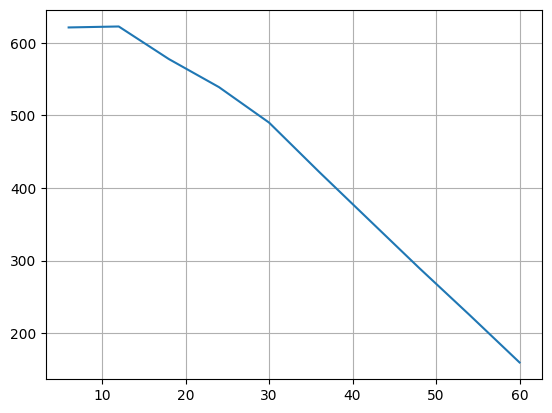

In [42]:
plt.plot(np.arange(6, 66, 6, dtype=int), time_taken)
plt.grid(which='both')
plt.show()

In [ ]:
time_taken_test2 = np.zeros(7)
for i in np.array([3, 6, 10, 12]):
    num_processes = 6
    pool = multiprocessing.Pool(processes=num_processes)
    chunks_per_processor = i
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test2[i] = end-start

time_taken_test2

Parsing 60 chunks with 6 processors and 3 chunks per processor


Applying BatDetect2: 100%|██████████| 60/60 [10:28<00:00, 10.48s/it]  

Time taken: 628.7419059276581s


Parsing 60 chunks with 6 processors and 6 chunks per processor


Applying BatDetect2: 100%|██████████| 60/60 [10:30<00:00, 10.51s/it]  

Time taken: 630.4077432155609s


Parsing 60 chunks with 6 processors and 10 chunks per processor


Applying BatDetect2: 100%|██████████| 60/60 [10:44<00:00, 10.74s/it]   


Time taken: 644.6665465831757s


IndexError: index 10 is out of bounds for axis 0 with size 7

In [10]:
input = file_path_mappings[:10]

In [13]:
time_taken_test2 = np.zeros(10)
for i in np.arange(1, 10+1):
    num_processes = 6
    pool = multiprocessing.Pool(processes=num_processes)
    chunks_per_processor = i
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test2[i-1] = end-start

time_taken_test2

Parsing 10 chunks with 6 processors and 1 chunks per processor


Applying BatDetect2: 100%|██████████| 10/10 [01:46<00:00, 10.64s/it]

Time taken: 106.36212730407715s


Parsing 10 chunks with 6 processors and 2 chunks per processor


Applying BatDetect2: 100%|██████████| 10/10 [01:46<00:00, 10.62s/it]

...

Time taken: 43.207886934280396s


Parsing 10 chunks with 6 processors and 10 chunks per processor


Applying BatDetect2: 100%|██████████| 10/10 [00:29<00:00,  2.91s/it]

Time taken: 29.14631414413452s


array([106.3621273 , 106.2146852 ,  99.9101665 ,  92.56355858,
        86.31048822,  76.15103102,  62.78464437,  53.47812223,
        43.20788693,  29.14631414])

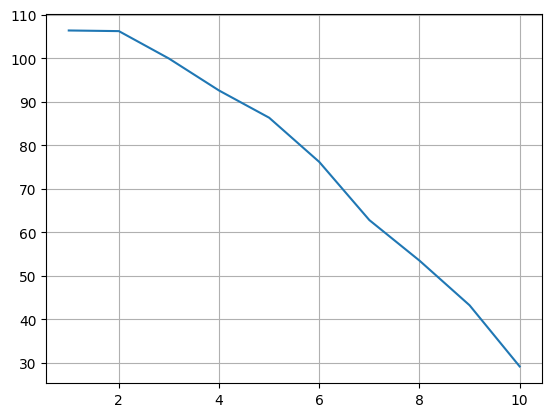

In [15]:
plt.plot(np.arange(1,11,1, dtype=int), time_taken_test2)
plt.grid(which='both')
plt.show()

In [14]:
input = file_path_mappings[:10]

In [18]:
num_processes = 1
pool = multiprocessing.Pool(processes=num_processes)
chunksize_default, extra = divmod(len(input), num_processes*4)
if extra:
    chunksize_default += 1
chunksize_custom = 10
(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')

'Parsing 10 chunks with 1 processors and 10 chunks per processor'

In [20]:
time_taken_test3 = np.zeros(multiprocessing.cpu_count())
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    chunksize_custom = 10
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test3[i] = end-start
time_taken_test3

Parsing 10 chunks with 1 processors and 10 chunks per processor


Applying BatDetect2:   0%|          | 0/10 [00:00<?, ?it/s]

Applying BatDetect2: 100%|██████████| 10/10 [00:29<00:00,  2.94s/it]

Time taken: 29.450985193252563s


Parsing 10 chunks with 2 processors and 10 chunks per processor


...

Time taken: 33.12413263320923s


Parsing 10 chunks with 8 processors and 10 chunks per processor


Applying BatDetect2: 100%|██████████| 10/10 [00:33<00:00,  3.36s/it]

Time taken: 33.55756092071533s


array([29.45098519, 29.91133118, 31.54264593, 30.19968033, 31.28117847,
       30.94618773, 33.12413263, 33.55756092])

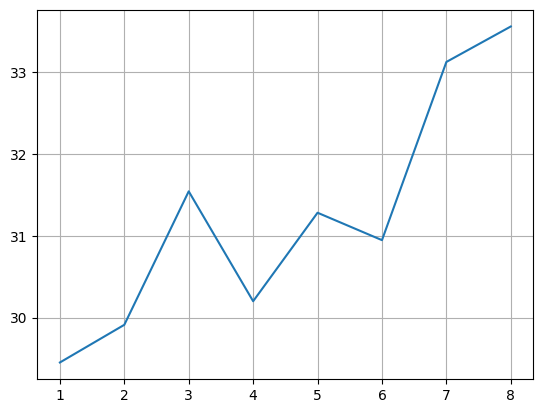

In [22]:
plt.plot(1+np.arange(multiprocessing.cpu_count(), dtype=int), time_taken_test3)
plt.grid(which='both')
plt.show()

In [9]:
input = file_path_mappings[:6]
num_processes = 6
pool = multiprocessing.Pool(processes=num_processes)
chunksize_custom = 6
print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
start = time.time()
results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                desc=f"Applying BatDetect2", total=len(input),)
bd_preds = gen_empty_df() 
bd_preds = pd.concat(results, ignore_index=True)
end = time.time()
print(f'Time taken: {end-start}s')

Parsing 6 chunks with 6 processors and 6 chunks per processor


Applying BatDetect2: 100%|██████████| 6/6 [00:17<00:00,  2.90s/it]

Time taken: 17.404139757156372s


In [10]:
input = file_path_mappings[:1]
time_taken_test3 = np.zeros(multiprocessing.cpu_count())
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    chunksize_custom = 1
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test3[i] = end-start
time_taken_test3

Parsing 1 chunks with 1 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/1 [00:00<?, ?it/s]

Applying BatDetect2: 100%|██████████| 1/1 [00:03<00:00,  3.36s/it]

Time taken: 3.3629403114318848s


Parsing 1 chunks with 2 processors and 1 chunks per processor


...

Time taken: 3.183532953262329s


Parsing 1 chunks with 8 processors and 1 chunks per processor


Applying BatDetect2: 100%|██████████| 1/1 [00:03<00:00,  3.56s/it]

Time taken: 3.5609796047210693s


array([3.36294031, 3.31589675, 3.12790728, 3.19213343, 3.31400585,
       3.25603628, 3.18353295, 3.5609796 ])

In [16]:
start = time.time()
run_models(file_path_mappings[:8])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 8/8 [00:21<00:00,  2.71s/it]


In [ ]:
input = file_path_mappings[:8]
time_taken_test3 = np.zeros((multiprocessing.cpu_count(), len(input)))
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    for j in np.arange(len(input)):
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                        desc=f"Applying BatDetect2", total=len(input),)
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test3[i,j] = end-start
        print(time_taken_test3)

In [9]:
time_taken_test3

array([[26.19007897, 25.25795054, 25.60026169, 25.91846275, 25.86191916,
        25.82421517, 25.30190611, 25.82965994],
       [68.73130751, 65.28847051, 57.83360338, 66.14617872, 58.57361078,
        46.79140639, 36.53096867, 26.46403694],
       [74.47274518, 63.21777797, 74.2156539 , 67.21233487, 57.30860519,
        44.96175718, 34.30764008, 23.49285841],
       [82.69398451, 81.75318456, 74.13882113, 66.00504923, 56.79313231,
        44.47519898, 34.97930646, 24.48460746],
       [82.49061608, 82.07761598, 74.24742222, 66.43820119, 58.07663846,
        44.11923265, 35.87306714, 25.40144944],
       [82.27139807, 81.8356421 , 74.99067926, 68.56530142, 55.48359203,
        47.17725205, 37.00665045, 24.74189806],
       [80.54516959, 81.86958551, 74.99611449, 66.58862352, 57.82390404,
        46.67585492, 35.99126244, 25.99431348],
       [89.0005784 , 81.15420651, 75.04536152, 67.78864622, 54.47782731,
        46.73271561, 35.8100059 , 26.38357854]])

In [13]:
start = time.time()
run_models(file_path_mappings[:4])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 4/4 [00:13<00:00,  3.43s/it]


In [ ]:
input = file_path_mappings[:4]
time_taken_test4 = np.zeros((multiprocessing.cpu_count(), len(input)))
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = int(i+1)
    pool = multiprocessing.Pool(processes=num_processes)
    for j in np.arange(len(input)):
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test4[i,j] = end-start
        print(time_taken_test4)

In [15]:
time_taken_test4

array([[12.36981153, 12.12704873, 12.28413558, 12.3935082 ],
       [35.5948472 , 34.16540575, 23.26142764, 12.68671489],
       [32.5104835 , 33.32189345, 23.70235062, 12.88899422],
       [41.66026926, 33.02592015, 23.07717562, 12.38802314],
       [42.16319942, 33.63915038, 22.59711623, 12.61536598],
       [41.89834094, 32.75463152, 23.91124701, 12.08476162],
       [42.03468657, 36.2736249 , 22.46214008, 15.84729457],
       [41.73307085, 34.88299727, 22.7636404 , 11.99592972]])

In [ ]:
input = file_path_mappings[:4]
time_taken_test5 = np.zeros((4, len(input)))
for i in np.arange(4):
    for j in np.arange(len(input)):
        num_processes = int(i+1)
        pool = multiprocessing.Pool(processes=num_processes)
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test5[i,j] = end-start
        print(time_taken_test5)

In [9]:
time_taken_test5

array([[13.32795405, 14.13810802, 14.13029909, 13.90709686],
       [35.00724554, 35.50248098, 24.81592178, 13.60137582],
       [33.54444146, 34.86006141, 24.59304643, 14.57824039],
       [41.89947438, 35.29683042, 24.6513145 , 13.71438718]])

In [10]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 60.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
bd_preds = pd.DataFrame()

if not cfg['output_dir'].is_dir():
    cfg['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

cfg["csv_filename"] = f"batdetect2_pipeline_{input_file.name.split('.')[0]}"
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
file_path_mappings[:2]

Generating detections for 20220728_080000.WAV


[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_60.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x787fcccebd90>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__60.00_120.00.wav'),
   'offset': 60.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x787fcccebd90>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')}]

In [ ]:
start = time.time()
run_models(file_path_mappings[:4])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 4/4 [00:27<00:00,  6.80s/it]


Baseline time 27.18936538696289s
Generating detections for 20220728_080000.WAV
Baseline time 13.728536605834961s
Generating detections for 20220728_080000.WAV
Parsing 4 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav


In [ ]:
input = file_path_mappings[:4]
time_taken_test5 = np.zeros((4, len(input)))
for i in np.arange(4):
    for j in np.arange(len(input)):
        num_processes = int(i+1)
        pool = multiprocessing.Pool(processes=num_processes)
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test5[i,j] = end-start
        print(time_taken_test5)

In [9]:
time_taken_test5

array([[27.97477579, 27.34691596, 26.71719193, 26.81638408],
       [68.46362686, 69.21919084, 48.64796281, 27.64044952],
       [66.35707188, 69.96169066, 47.27242136, 27.54954386],
       [82.09993434, 68.09816241, 48.36430717, 26.5833292 ]])